In [2]:
import numpy as np
import matplotlib.pyplot as plt
# importing rastermap
# (this will be slow the first time since it is compiling the numba functions)
from rastermap import Rastermap, utils
from scipy.stats import zscore

In [3]:
# download processed hippocampus recording from Grosmark & Buzsaki 2016
filename = utils.download_data(data_type="hippocampus")

dat = np.load(filename)

# spks is neurons by time
# (each timepoint is 200 ms)
spks = dat["spks"]
n_neurons, n_time = spks.shape
print(f"{n_neurons} neurons by {n_time} timepoints")
# zscore activity (each neuron activity trace is then mean 0 and standard-deviation 1)
spks = zscore(spks, axis=1)

# location of the rat and speed
loc2d = dat["loc2d"] # 2D location
loc_signed = dat["loc_signed"] # left runs are positive and right runs are negative
speed = (np.diff(loc2d, axis=0)**2).sum(axis=1)**0.5
speed = np.concatenate((np.zeros((1,)), speed), axis=0)

# which neurons in the recording are pyramidal cells
pyr_cells = dat["pyr_cells"].astype("int")

100%|█████████████████████████████████████████████████████████████████████████████| 5.73M/5.73M [00:00<00:00, 23.5MB/s]

137 neurons by 10338 timepoints


In [4]:
spks.shape

(137, 10338)

In [5]:
model = Rastermap(n_clusters=None, # None turns off clustering and sorts single neurons 
                  n_PCs=64, # use fewer PCs than neurons
                  locality=0.1, # some locality in sorting (this is a value from 0-1)
                  time_lag_window=15, # use future timepoints to compute correlation
                  grid_upsample=0, # 0 turns off upsampling since we're using single neurons
                ).fit(spks)
y = model.embedding # neurons x 1
isort = model.isort

2024-11-11 13:29:59,934 [INFO] normalizing data across axis=1
2024-11-11 13:29:59,940 [INFO] projecting out mean along axis=0
2024-11-11 13:29:59,947 [INFO] data normalized, 0.01sec
2024-11-11 13:29:59,948 [INFO] sorting activity: 137 valid samples by 10338 timepoints
2024-11-11 13:30:00,213 [INFO] n_PCs = 64 computed, 0.28sec
2024-11-11 13:30:00,217 [INFO] skipping clustering, n_clusters is None
2024-11-11 13:30:27,519 [INFO] clusters sorted, time 27.58sec
2024-11-11 13:30:27,537 [INFO] rastermap complete, time 27.60sec


In [6]:
n_pos = 15
bins = np.arange(-1, 1+1./n_pos, 1./n_pos)
ibin = np.digitize(loc_signed, bins) - 1
n_bins = ibin.max()
inan = np.isnan(loc_signed)
ibin[inan] = -1
tcurves = np.zeros((spks.shape[0], n_bins))
for b in range(n_bins):
    tcurves[:, b] = spks[:, ibin==b].mean(axis=1)
tcurves -= tcurves.mean(axis=1, keepdims=True)

(np.float64(-1.5250000000000001),
 np.float64(32.025),
 np.float64(0.0),
 np.float64(137.0))

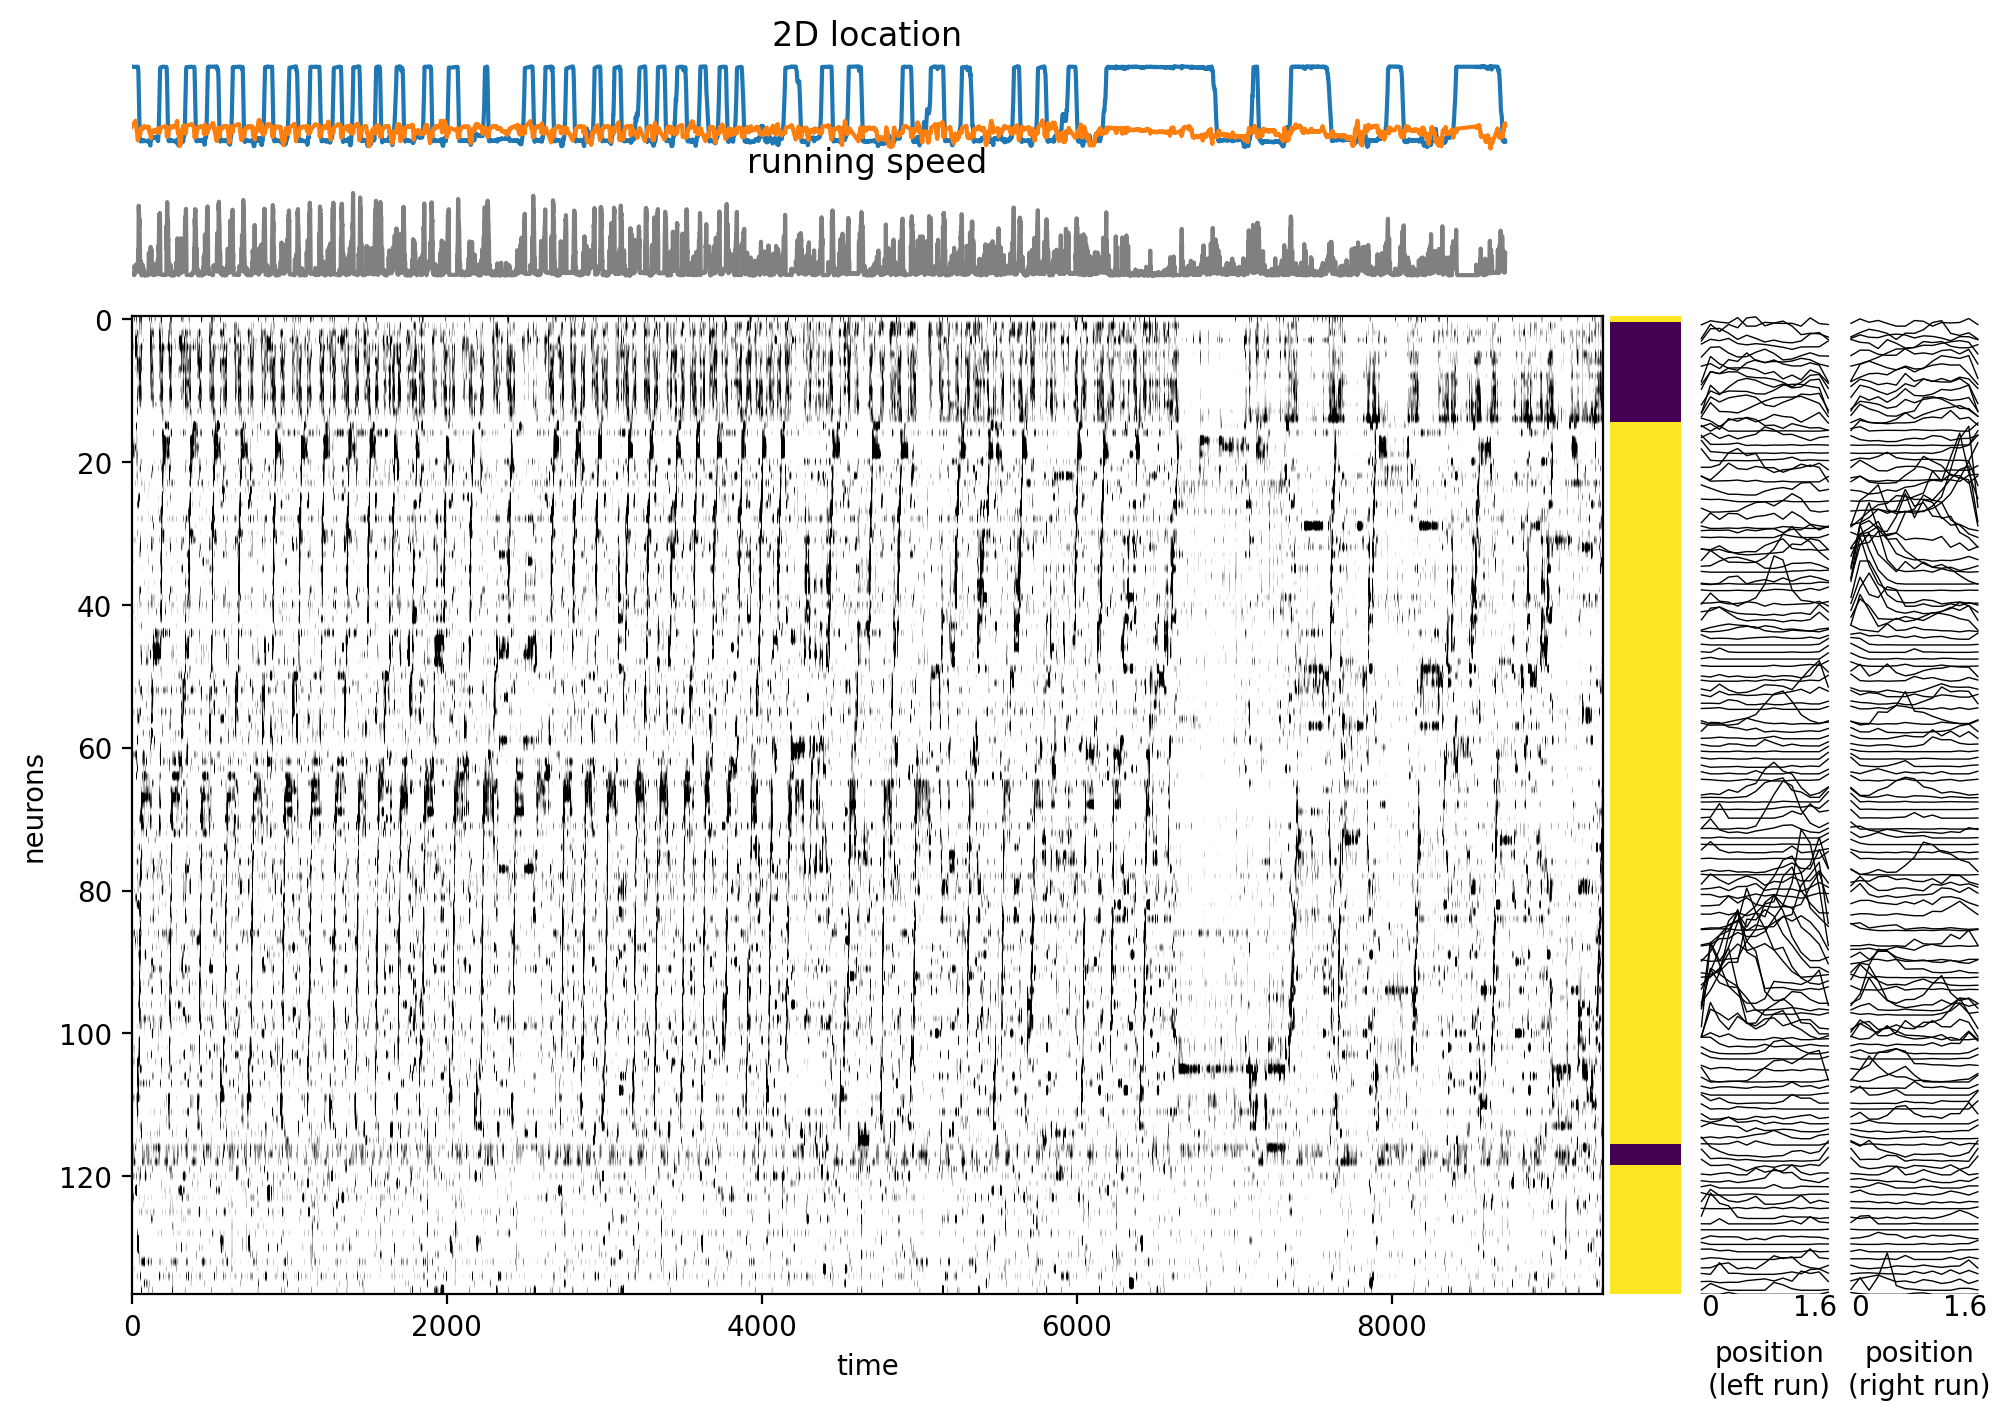

In [10]:
# timepoints to visualize
xmin = 1000
xmax = xmin + 10000

# make figure with grid for easy plotting
fig = plt.figure(figsize=(12,8), dpi=200)
grid = plt.GridSpec(10, 24, figure=fig, wspace = 0.1, hspace = 0.4)

# plot location
ax = plt.subplot(grid[0, :-5])
ax.plot(loc2d[xmin:xmax])#, color=kp_colors[0])
ax.set_xlim([0, xmax-xmin])
ax.axis("off")
ax.set_title("2D location")

# plot running speed
ax = plt.subplot(grid[1, :-5])
ax.plot(speed[xmin:xmax], color=0.5*np.ones(3))
ax.set_xlim([0, xmax-xmin])
ax.axis("off")
ax.set_title("running speed")

# plot sorted neural activity
ax = plt.subplot(grid[2:, :-5])
ax.imshow(spks[isort, xmin:xmax], cmap="gray_r", vmin=0, vmax=1.2, aspect="auto")
ax.set_xlabel("time")
ax.set_ylabel("neurons")

# excitatory cells in yellow, and inhibitory cells in dark blue
# (could replace this with a colorbar or other property)
ax = plt.subplot(grid[2:, -5])
ax.imshow(pyr_cells[isort, np.newaxis],
          cmap="viridis", aspect="auto")
ax.axis("off")

# plot single-neuron tuning curves
ax = plt.subplot(grid[2:, -4:])
x = np.arange(0, n_pos)
dy = 2
xpad = n_pos/10
nn = spks.shape[0]
for t in range(len(tcurves)):
    ax.plot(x, tcurves[isort[t], :n_pos]*dy - dy/2 + nn - t, 
            color="k", lw=0.5)
    ax.plot(x+n_pos+xpad, tcurves[isort[t], n_pos:]*dy - dy/2 + nn - t, 
            color="k", lw=0.5)
for j in range(2):
    xstr = "position\n(left run)" if j==0 else "position\n(right run)"
    ax.text(n_pos/2 + j*(n_pos+xpad), -14, xstr, ha="center")
    ax.text(j*(n_pos+xpad), -3, "0")
    ax.text(n_pos + j*(n_pos+xpad), -3, "1.6", ha="right")
ax.set_ylim([0, nn])
ax.axis("off")